In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = Path("..").resolve()
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(exist_ok=True)

print(RESULTS_DIR)

C:\Users\GArvit\Desktop\Fall Detection\results


In [3]:
comparison_data = {
    "Model": [
        "Custom CNN",
        "MobileNetV3",
        "ResNet50"
    ],
    "Accuracy": [
        0.5706,
        0.6981,
        0.8809
    ],
    "Fall Precision": [
        0.3846,
        0.5877,
        0.7845
    ],
    "Fall Recall": [
        0.1027,
        0.8493,
        0.9726
    ],
    "Fall F1-Score": [
        0.1622,
        0.6947,
        0.8685
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Model,Accuracy,Fall Precision,Fall Recall,Fall F1-Score
0,Custom CNN,0.5706,0.3846,0.1027,0.1622
1,MobileNetV3,0.6981,0.5877,0.8493,0.6947
2,ResNet50,0.8809,0.7845,0.9726,0.8685


In [4]:
percentage_df = comparison_df.copy()

metric_columns = [
    "Accuracy",
    "Fall Precision",
    "Fall Recall",
    "Fall F1-Score"
]

for column in metric_columns:
    percentage_df[column] = (
        percentage_df[column] * 100
    ).round(2)

percentage_df

,Model,Accuracy,Fall Precision,Fall Recall,Fall F1-Score
0,Custom CNN,57.06,38.46,10.27,16.22
1,MobileNetV3,69.81,58.77,84.93,69.47
2,ResNet50,88.09,78.45,97.26,86.85


In [8]:
csv_path = RESULTS_DIR / "model_comparison.csv"

percentage_df.to_csv(
    csv_path,
    index=False
)

print("Saved:", csv_path)

Saved: C:\Users\GArvit\Desktop\Fall Detection\results\model_comparison.csv


In [9]:
text_path = RESULTS_DIR / "model_comparison.txt"

with open(text_path, "w") as file:
    file.write("MODEL COMPARISON\n")
    file.write("=" * 70 + "\n\n")

    file.write(
        percentage_df.to_string(index=False)
    )

    file.write("\n\nBEST MODEL\n")
    file.write("=" * 70 + "\n")
    file.write("ResNet50\n\n")

    file.write("Reasons:\n")
    file.write("- Highest accuracy: 88.09%\n")
    file.write("- Highest fall recall: 97.26%\n")
    file.write("- Highest fall F1-score: 86.85%\n")
    file.write("- Only 4 actual falls were missed\n")

print("Saved:", text_path)

Saved: C:\Users\GArvit\Desktop\Fall Detection\results\model_comparison.txt


In [10]:
text_path = RESULTS_DIR / "model_comparison.txt"

with open(text_path, "w") as file:
    file.write("MODEL COMPARISON\n")
    file.write("=" * 70 + "\n\n")

    file.write(
        percentage_df.to_string(index=False)
    )

    file.write("\n\nBEST MODEL\n")
    file.write("=" * 70 + "\n")
    file.write("ResNet50\n\n")

    file.write("Reasons:\n")
    file.write("- Highest accuracy: 88.09%\n")
    file.write("- Highest fall recall: 97.26%\n")
    file.write("- Highest fall F1-score: 86.85%\n")
    file.write("- Only 4 actual falls were missed\n")

print("Saved:", text_path)

Saved: C:\Users\GArvit\Desktop\Fall Detection\results\model_comparison.txt


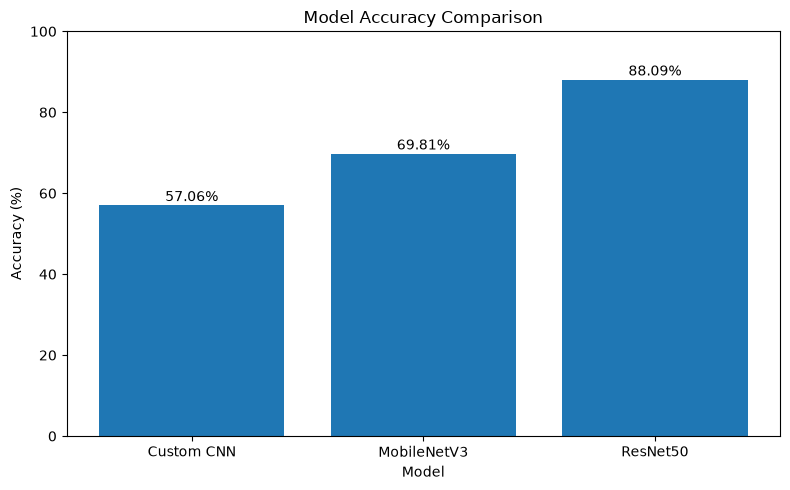

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    percentage_df["Model"],
    percentage_df["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

for index, value in enumerate(
    percentage_df["Accuracy"]
):
    plt.text(
        index,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x600 with 0 Axes>

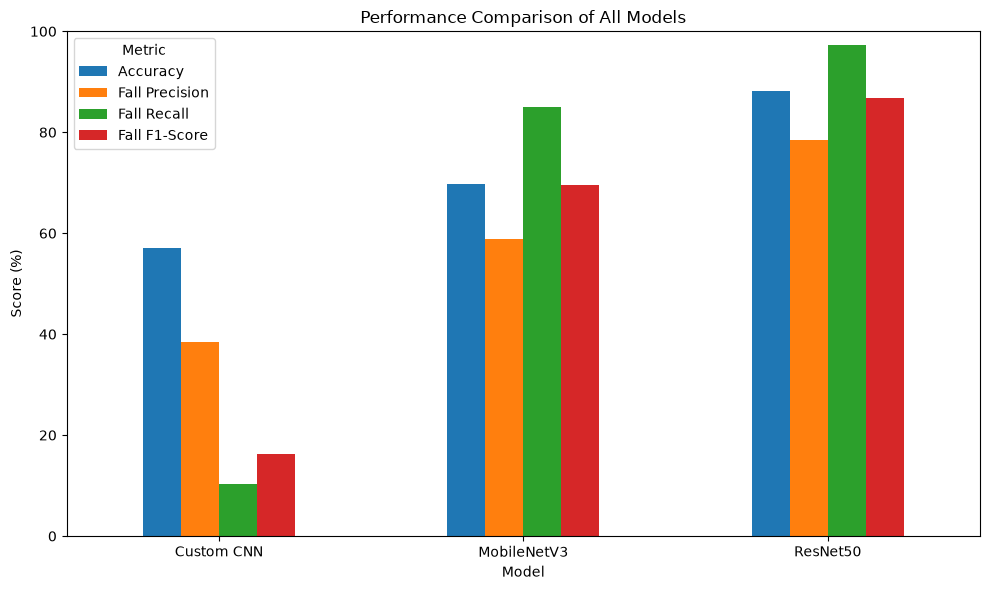

In [12]:
plot_df = percentage_df.set_index("Model")

plt.figure(figsize=(10, 6))

plot_df[
    [
        "Accuracy",
        "Fall Precision",
        "Fall Recall",
        "Fall F1-Score"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.title("Performance Comparison of All Models")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "all_models_metric_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
files_to_check = [
    "model_comparison.csv",
    "model_comparison.txt",
    "model_accuracy_comparison.png",
    "all_models_metric_comparison.png"
]

for filename in files_to_check:
    path = RESULTS_DIR / filename
    print(filename, "->", path.exists())

model_comparison.csv -> True
model_comparison.txt -> True
model_accuracy_comparison.png -> True
all_models_metric_comparison.png -> True
